In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Load final data from conveyer
df = pd.read_csv('data/processed/cleaned_data.csv')

X = df.drop('default', axis=1)
y = df['default']

# Split data on Train (70%), Validation (15%), Test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

print(f"Розміри вибірок: Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# 3. Initialization of models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, solver='saga', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

# 4. Training and evaluation on the validation set
results = []
trained_models = {}

for name, model in models.items():
    start_time = time.time()
    
    # Training
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Pridiction
    y_pred = model.predict(X_val)
    
    # Metric collecting
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_val, y_pred), 4),
        "Precision": round(precision_score(y_val, y_pred), 4),
        "Recall": round(recall_score(y_val, y_pred), 4),
        "F1-score": round(f1_score(y_val, y_pred), 4),
        "Training time (s)": round(train_time, 4)
    })
    trained_models[name] = model

# Show rate table of basic models
results_df = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)
display(results_df)

Розміри вибірок: Train: (32683, 28), Val: (7006, 28), Test: (7004, 28)


C:\Users\svitj\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-score,Training time (s)
2,XGBoost,0.8792,0.9321,0.8183,0.8715,0.7770
1,Random Forest,0.8777,0.9254,0.8217,0.8705,4.6202
0,Logistic Regression,0.7241,0.8235,0.5709,0.6743,37.7772


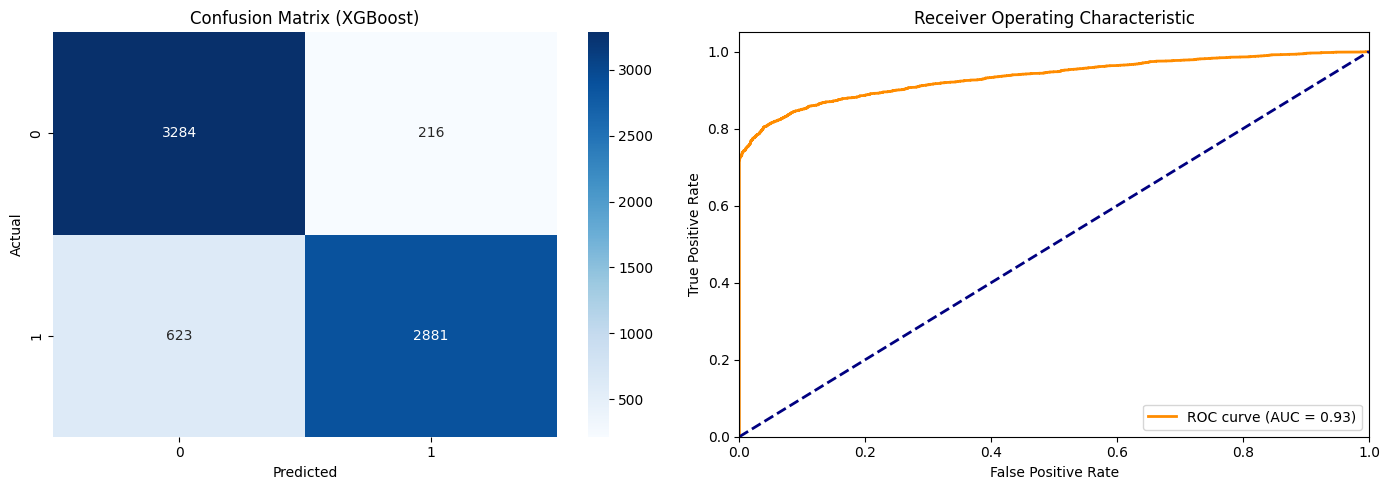

In [9]:
# Choose best model
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix ({best_model_name})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

--- Simulation: Data Drift ---
Original F1-score on Test: 0.8729
F1-score AFTER Data Drift: 0.8378


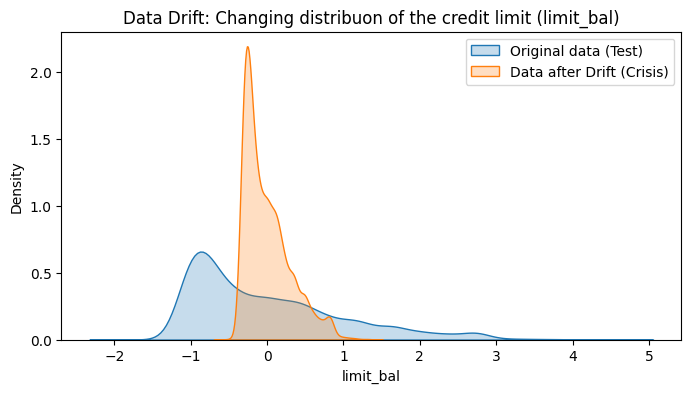

In [10]:
print("--- Simulation: Data Drift ---")

# Simulation: Economic Crisis (All customer credit limits are reduced by two-thirds, and payment delays are increasing)
X_test_drifted = X_test.copy()
X_test_drifted['limit_bal'] = X_test_drifted['limit_bal'] * 0.3
if 'avg_delay' in X_test_drifted.columns:
    X_test_drifted['avg_delay'] = X_test_drifted['avg_delay'] + 1 

# Evaluating the same model on new (shuffled) data
y_pred_drifted = best_model.predict(X_test_drifted)

print(f"Original F1-score on Test: {f1_score(y_test, y_pred_test):.4f}")
print(f"F1-score AFTER Data Drift: {f1_score(y_test, y_pred_drifted):.4f}")

# Data Drift Visualization (Distribution Chart)
plt.figure(figsize=(8, 4))
sns.kdeplot(X_test['limit_bal'], label='Original data (Test)', fill=True)
sns.kdeplot(X_test_drifted['limit_bal'], label='Data after Drift (Crisis)', fill=True)
plt.title('Data Drift: Changing distribuon of the credit limit (limit_bal)')
plt.legend()
plt.show()

In [11]:
from sklearn.model_selection import GridSearchCV

print("--- Random Forest optimization by GridSearchCV ---")

# Set the parameter grid (keep it small so it learns quickly)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, 
                           scoring='f1', cv=3, verbose=1, n_jobs=-1)

# Train on a combined Train + Val dataset for better results
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

grid_search.fit(X_train_full, y_train_full)

print(f"\nBest parameters: {grid_search.best_params_}")

# Comparison on the test set
rf_optimized = grid_search.best_estimator_
y_pred_opt = rf_optimized.predict(X_test)

print("\n--- Result comparing ---")
print(f"Random Forest BEFORE optimization (F1): {results_df[results_df['Model']=='Random Forest']['F1-score'].values[0]:.4f}")
print(f"Random Forest AFTER optimization (F1):  {f1_score(y_test, y_pred_opt):.4f}")

--- Random Forest optimization by GridSearchCV ---
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

--- Result comparing ---
Random Forest BEFORE optimization (F1): 0.8705
Random Forest AFTER optimization (F1):  0.8781


In [13]:
print("--- XGBoost optimization by GridSearchCV ---")

# Set the parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_base = XGBClassifier(eval_metric='logloss', random_state=42)

# Set GridSearchCV
grid_search_xgb = GridSearchCV(estimator=xgb_base, param_grid=param_grid_xgb, 
                               scoring='f1', cv=3, verbose=1, n_jobs=-1)

# Train on array (Train + Val)
grid_search_xgb.fit(X_train_full, y_train_full)

print(f"\nBest parameters: {grid_search_xgb.best_params_}")

# Comparison on the test set
xgb_optimized = grid_search_xgb.best_estimator_
y_pred_opt_xgb = xgb_optimized.predict(X_test)

print("\n--- Result comparing ---")
old_f1_xgb = results_df[results_df['Model']=='XGBoost']['F1-score'].values[0]

print(f"XGBoost BEFORE optimization (F1): {old_f1_xgb:.4f}")
print(f"XGBoost AFTER optimization (F1):  {f1_score(y_test, y_pred_opt_xgb):.4f}")

--- XGBoost optimization by GridSearchCV ---
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

--- Result comparing ---
XGBoost BEFORE optimization (F1): 0.8715
XGBoost AFTER optimization (F1):  0.8788
